**Навигация по уроку**

1. [Обработка аудиосигналов](https://colab.research.google.com/drive/13r2TM72wK5mFSMsb1rBV4gspNCqkzJDY)
2. [Распознавание музыкального жанра](https://colab.research.google.com/drive/1VVV3EUT9uaVHNwZBweAsfOcDYwtPMJ2z)
3. [Генерация музыкальных произведений с помощью НС](https://colab.research.google.com/drive/1mxiZYMIVk_RhgNB_kXsySMkA-O2HkpHF)
4. Домашняя работа

**В домашней работе необходимо выполнить следующее задание:**

1. Используя предложенный [датасет](https://storage.yandexcloud.net/academy.ai/classical-music-midi.zip) произведений классической музыки, обучи модель "сочинять" музыку на произведениях только одного Шопена.
2. В качестве начальной последовательности для генерации используйте произведения Моцарта.
3. Для получения трех баллов достаточно получить ноты и аудиофайл с вашим сгенерированным произведением.
4. Хотите 4 балла? Добавьте в функцию генерации параметр `temperature` - температура модели. Температура модели влияет на генерацию. Более низкие температуры соответствуют более точному предсказанию, а более высокие температуры приводят к более случайной генерации.
5. Хотите 5 баллов? Используйте для обучения модели три переменные для представления ноты: pitch, step и duration. Высота звука (pitch) - это качество восприятия звука в виде номера ноты в формате MIDI. Шаг (step) - это время, прошедшее с предыдущей ноты или начала трека. Длительность (duration) - это продолжительность воспроизведения ноты в секундах и разница между временем окончания и началом ноты.

In [ ]:
!sudo apt install -y fluidsynth
!pip install --upgrade pyfluidsynth
!pip install --upgrade music21

!add-apt-repository ppa:mscore-ubuntu/mscore-stable -y
!apt-get update
!apt-get install musescore

!apt-get install xvfb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fluid-soundfont-gm libevdev2 libfluidsynth3 libgudev-1.0-0 libinput-bin
  libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5
  libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1
  libxcb-render-util0 libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1
  libxkbcommon-x11-0 qsynth qt5-gtk-platformtheme qttranslations5-l10n
  timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  fluid-soundfont-gm fluidsynth libevdev2 libfluidsynth3 libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libx

In [ ]:
from music21 import *

# настраиваем окружение в соответствии с документацией
us = environment.UserSettings()
us['musescoreDirectPNGPath'] = '/usr/bin/mscore'
us['directoryScratch'] = '/tmp'

In [ ]:
# Импортируем библиотеки
import tensorflow
import os
import numpy as np
import pandas as pd
from collections import Counter
import random
import IPython
from IPython.display import Image, Audio
import music21
from music21 import *
import fluidsynth

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import keras.backend as K
from keras.optimizers import Adamax

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

import sys
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
np.random.seed(42)

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/classical-music-midi.zip

--2025-03-05 04:48:45--  https://storage.yandexcloud.net/academy.ai/classical-music-midi.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2751606 (2.6M) [application/x-zip-compressed]
Saving to: ‘classical-music-midi.zip’

classical-music-mid 100%[===================>]   2.62M  1.86MB/s    in 1.4s    

2025-03-05 04:48:47 (1.86 MB/s) - ‘classical-music-midi.zip’ saved [2751606/2751606]



In [ ]:
# Разархивируем датасета во временную папку 'dataset'
!unzip -qo "classical-music-midi" -d ./dataset

In [ ]:
!dir ./dataset

Albeniz    Borodin	Christmas  Granados  Mendelssohn  Rachmaninoff	Sinding
Bach	   Brahms	Clementi   Grieg     Moszkowski   Ravel		Tchaikovsky
Balakirev  Burgmueller	Debussy    Haydn     Mozart	  Schubert
Beethoven  Chopin	Godowsky   Liszt     Mussorgsky   Schumann


In [ ]:
CLASS_LIST=["Chopin"]

In [ ]:
all_midis = []
for compositor in CLASS_LIST:
    filepath = f"./dataset/{compositor}/"
    for i in os.listdir(filepath):
        if i.endswith(".mid"):
            tr = filepath+i

            # чтение и парсинг midi-файлов в Stream-объект библиотеки music21
            midi = converter.parse(tr)
            all_midis.append(midi)


In [ ]:
def getNotes(file):
    notes = []
    notes_to_parse = None
    for j in file:

        # получение инструментов из Stream-объекта
        songs = instrument.partitionByInstrument(j)

        # цикл по всем инструментам
        for part in songs.parts:
            # используем рекурсивный итератор в соответствии с документацией
            notes_to_parse = part.recurse()
            # части Stream-объекта, с которым мы работает состоит из разных элементов
            # отберем только интересующие нас элементы note.Note (нота) и chord.Chord (целый аккорд, последовательность нот)
            for element in notes_to_parse:
                if isinstance(element, note.Note):
                    # извлекаем ноту как тон (терминология библиотеки)
                    notes.append(str(element.pitch))
                elif isinstance(element, chord.Chord):
                    # аккорд функционирует как объект-нота, но имеет несколько последовательных тонов
                    notes.append(".".join(str(n) for n in element.normalOrder))

    return notes

In [ ]:
Corpus = getNotes(all_midis)
print("Всего нот во всех midi-файлах всего датасета:", len(Corpus))

Всего нот во всех midi-файлах всего датасета: 57894


In [ ]:
print("Первые 50 нот в корпусе:", Corpus[:50])

Первые 50 нот в корпусе: ['5.10', '5.10', '6.10', '1.6', 'B-3', 'F3', 'B-3', '5.10', 'F#3', '1.6', '5.10', '5.10', '6.10', '1.6', 'B-3', 'F3', 'B-3', '5.10', 'F#3', '1.6', '5.10', '5.10', '6.10', '1.6', 'B-3', '5.10', '5.10', '1.6', '1.6', 'C4', '0.5', '5.10', 'B-3', '6.10', '1.6', 'B-3', 'F3', 'B-3', '5.10', 'F#3', '1.6', '10.1.5', '5.10', '6.10.1', '1.6', 'C#4', '10.1.5', '5.10', '1.5.6', '1.6']


In [ ]:
# Функция преобразования отрывка из корпуса обратно в поток
def chords_n_notes(chunk):
    Melody = []
    offset = 0 # счетчик
    for i in chunk:
        # Если это аккорд разделенный точкой
        if ("." in i or i.isdigit()):
            chord_notes = i.split(".") # Разделяем аккорд на части
            notes = []
            for j in chord_notes:
                inst_note=int(j)
                # Преобразуем ноту в обект Note (нота)
                note_chunk = note.Note(inst_note)
                notes.append(note_chunk)
                # объединяем ноты в аккорды
                chord_chunk = chord.Chord(notes)
                # задаем позицию аккорда
                chord_chunk.offset = offset
                Melody.append(chord_chunk)
        # если это нота, а не аккорд
        else:
            # из текстового обозначения ноты делаем объект Note (ноту)
            note_chunk = note.Note(i)
            # задаем позицию ноты
            note_chunk.offset = offset
            Melody.append(note_chunk)
        # увеличиваем номер позиции
        offset += 1


    return Melody

# Преобразуем последовательность из 100 нот обратно в поток Stream
Music = chords_n_notes(Corpus[:100])
Melody_midi = stream.Stream(Music)

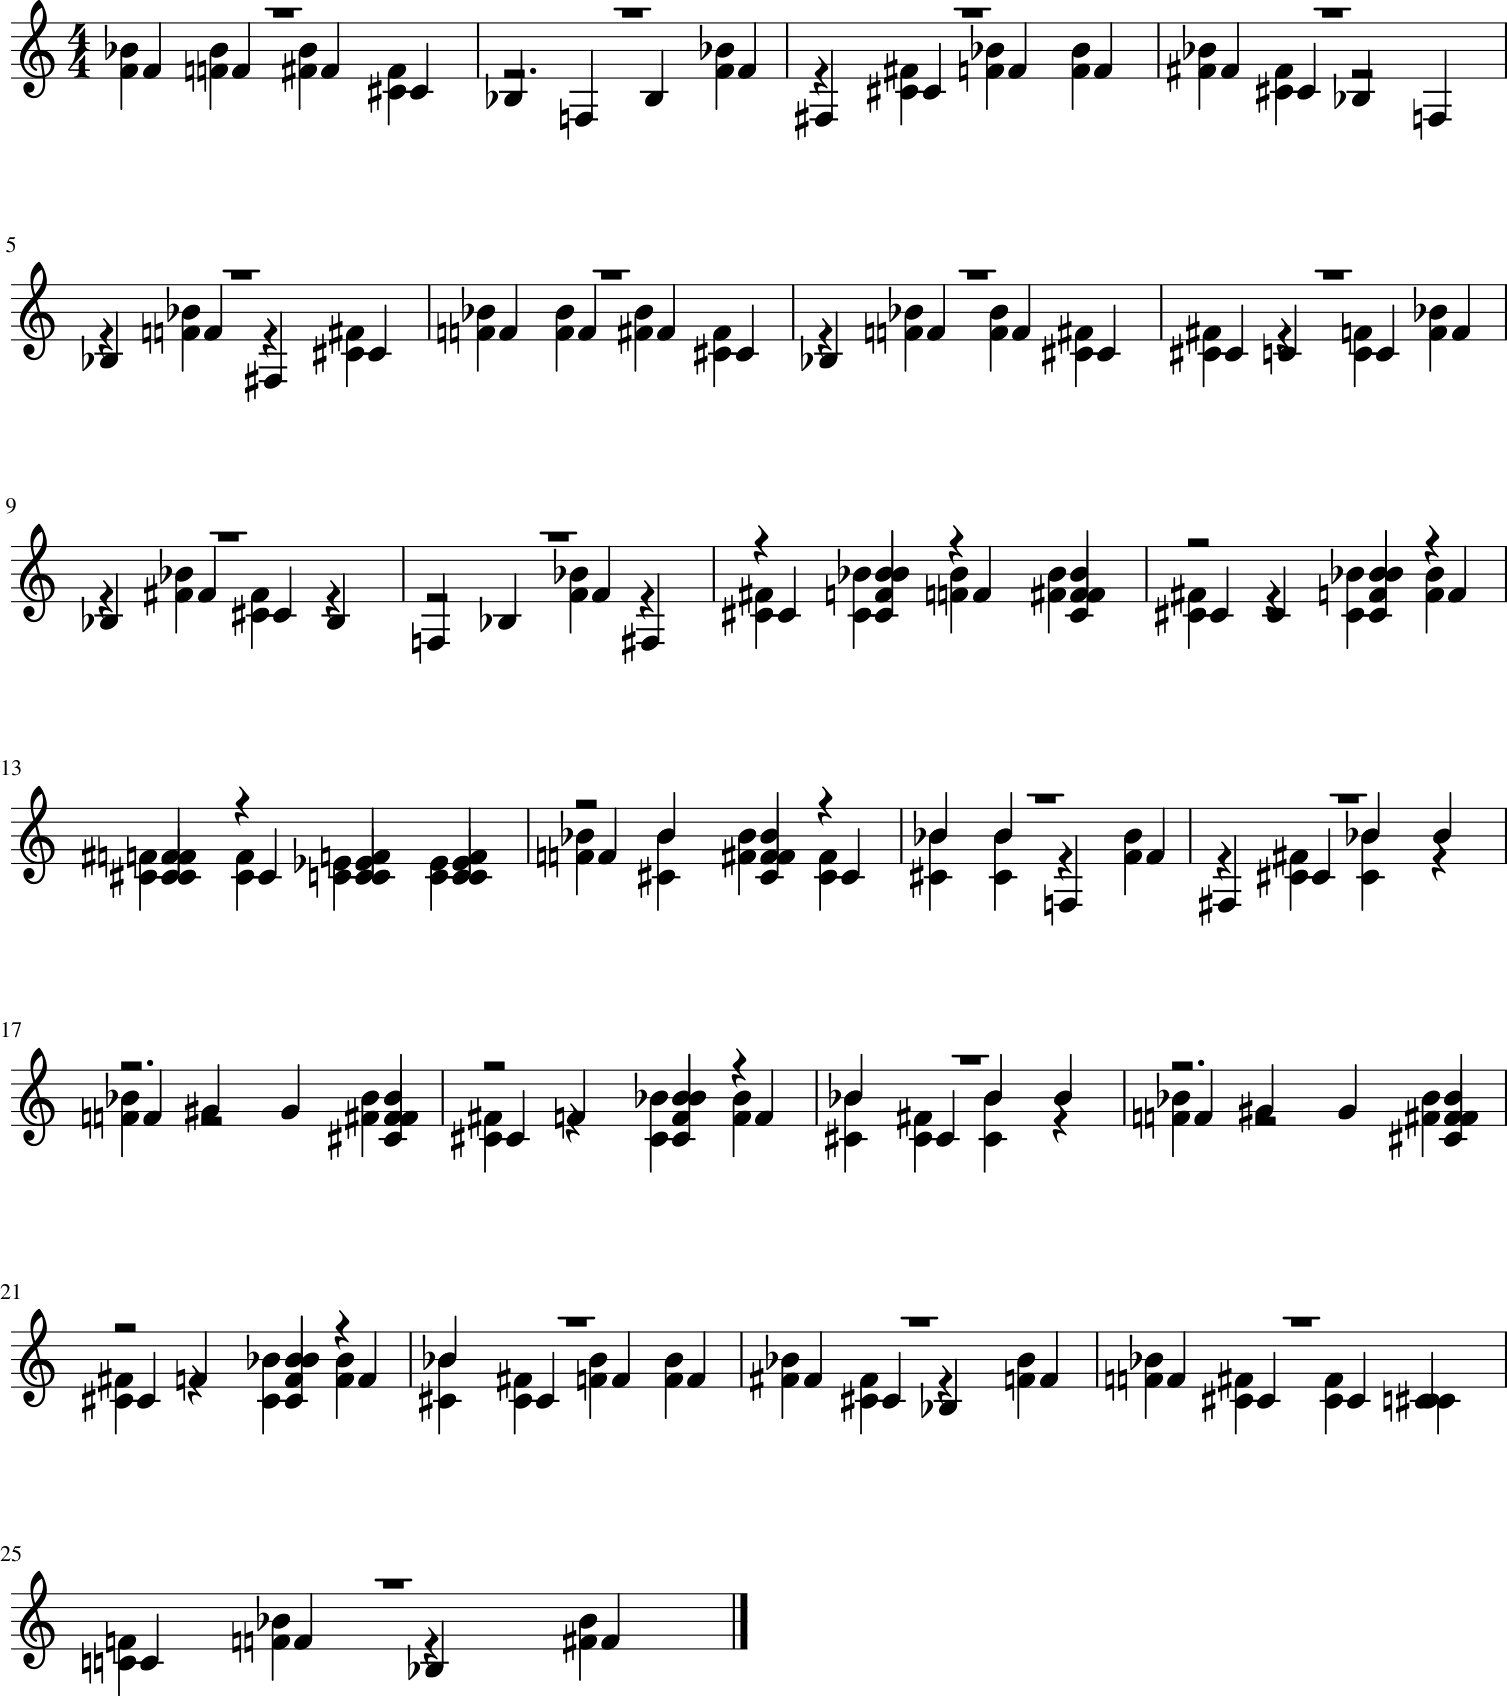

In [ ]:
# Отобразим нотный стан
Melody_midi.show()

In [ ]:
# Выведем в виде звуковой дорожки
Melody_midi.show('midi')

In [ ]:
from collections import Counter
count_num = Counter(Corpus)
print("Общее число уникальных нот в корпусе:", len(count_num))

Общее число уникальных нот в корпусе: 397


In [ ]:
# Ключ в словаре - имена нот
# Значение в словаре - их количество

Notes = list(count_num.keys())
Recurrence = list(count_num.values())

# Средняя частота встречаемости нот в корпусе
def Average(rec):
    return sum(rec) / len(rec)

print('Средняя повторяемость ноты:', Average(Recurrence))
print('Наиболее часто встречаемые ноты:', max(Recurrence), 'раз')
print('Наиболее редкие ноты:', min(Recurrence), 'раз')

Средняя повторяемость ноты: 145.8287153652393
Наиболее часто встречаемые ноты: 1627 раз
Наиболее редкие ноты: 1 раз


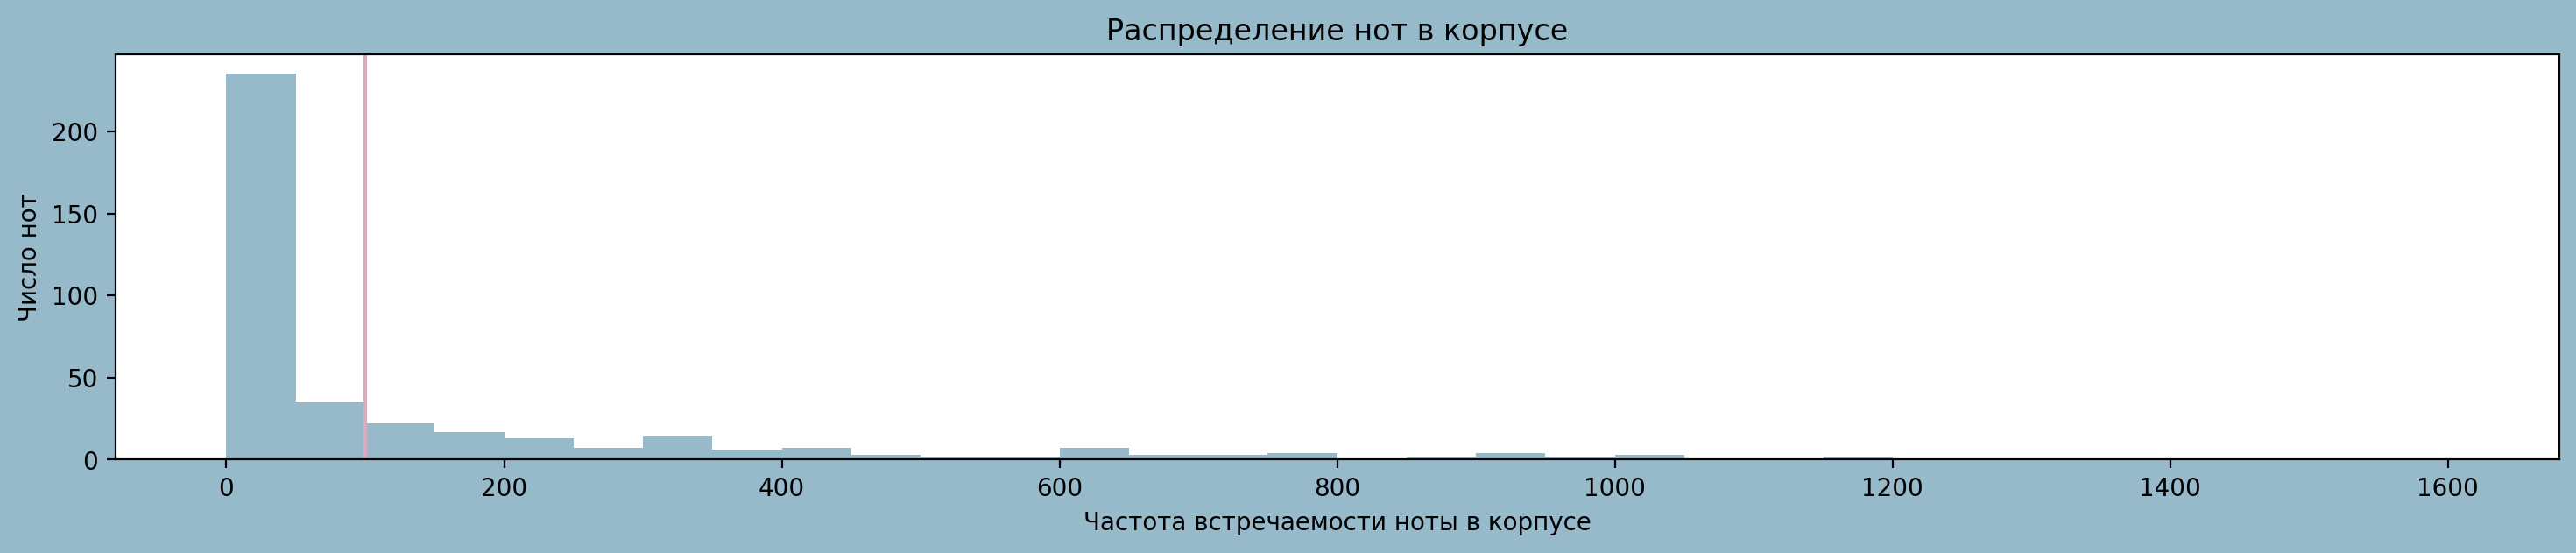

In [ ]:
plt.figure(figsize=(18, 3), facecolor='#97BACB')
bins = np.arange(0,(max(Recurrence)), 50)
plt.hist(Recurrence, bins=bins, color='#97BACB')
plt.axvline(x=100, color='#DBACC1') # отсечка по встречаемости в 100 раз
plt.title('Распределение нот в корпусе')
plt.xlabel('Частота встречаемости ноты в корпусе')
plt.ylabel('Число нот')
plt.show()

In [ ]:
# Получение списка редких нот
rare_note = []
for index, (key, value) in enumerate(count_num.items()):
    if value < 100:
        m =  key
        rare_note.append(m)

print("Общее число нот, которые повторяются менее 100 раз:", len(rare_note))

Общее число нот, которые повторяются менее 100 раз: 270


In [ ]:
for element in Corpus:
    if element in rare_note:
        Corpus.remove(element)

print("Длина корпуса после исключения редких нот:", len(Corpus))

Длина корпуса после исключения редких нот: 53745


In [ ]:
# Сохраняем все уникальные значения корпуса
symb = sorted(list(set(Corpus)))

L_corpus = len(Corpus) # длина корпуса
L_symb = len(symb) # число уникальных элементов корпуса

# Создание словаря для доступа к словарному запасу из индексов и наоборот
mapping = dict((c, i) for i, c in enumerate(symb))
reverse_mapping = dict((i, c) for i, c in enumerate(symb))

print("Общее число символов:", L_corpus)
print("Число уникальных символов:", L_symb)

Общее число символов: 53745
Число уникальных символов: 255


In [ ]:
# Разбиение корпуса на равные входные строки и выходные целевые последовательности

# длинны последовательностей
length = 40

# входные последовательности
features = []

# целевые последовательности
targets = []

# цикл разбиения корпуса
for i in range(0, L_corpus - length, 1):
    feature = Corpus[i:i + length]
    target = Corpus[i + length]
    features.append([mapping[j] for j in feature])
    targets.append(mapping[target])


L_datapoints = len(targets)
print("Общее количество последовательностей в корпусе:", L_datapoints)

Общее количество последовательностей в корпусе: 53705


In [ ]:
# изменение размера и нормализация входных данных
X = (np.reshape(features, (L_datapoints, length, 1)))/ float(L_symb)

# one-hot encode для целевых выходных данных
y = tensorflow.keras.utils.to_categorical(targets)

In [ ]:
print(f'Форма входных данных: {X.shape}')
print(f'Форма выходных данных: {y.shape}')

Форма входных данных: (53705, 40, 1)
Форма выходных данных: (53705, 255)


In [ ]:
X_train, X_seed, y_train, y_seed = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = Sequential()

model.add(LSTM(256, input_shape=X.shape[1:], return_sequences=True))
model.add(Dropout(0.1))
model.add(LSTM(128))
model.add(Dense(128))
model.add(Dropout(0.1))
model.add(Dense(y.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['acc'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 40, 256)             │         264,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 40, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 128)                 │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 255)                 │          32,895 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 510,719 (1.95 MB)

 Trainable params: 510,719 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, batch_size=256, epochs=150)

Epoch 1/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - acc: 0.0227 - loss: 4.8886
Epoch 2/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0266 - loss: 4.6838
Epoch 3/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0272 - loss: 4.6848
Epoch 4/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0263 - loss: 4.6783
Epoch 5/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0289 - loss: 4.6396
Epoch 6/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.0382 - loss: 4.4596
Epoch 7/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0368 - loss: 4.4408
Epoch 8/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0373 - loss: 4.4303
Epoch 9/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0370 - loss: 4.4243
Epoch 10/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.0388 - loss: 4.4221
Epoch 11/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0411 - loss: 4.4082
Epoch 12/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.0391 - loss: 4.3962
E

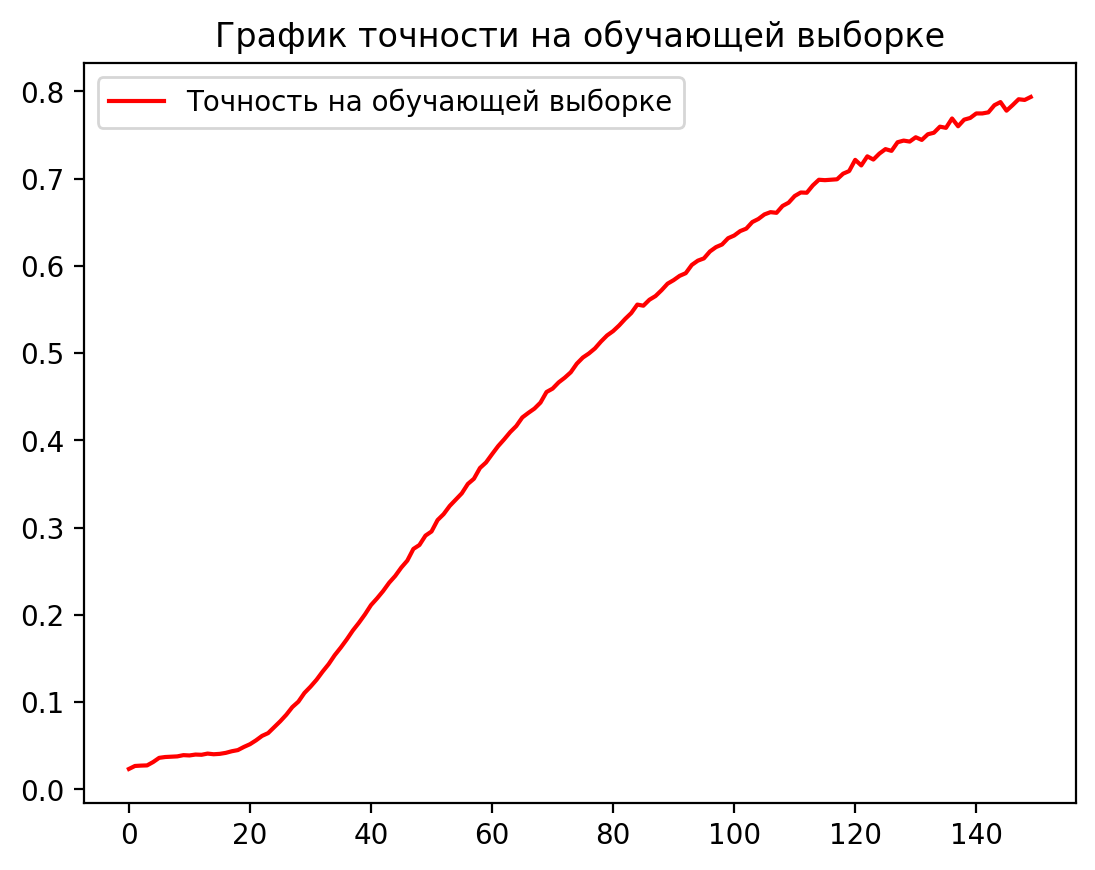

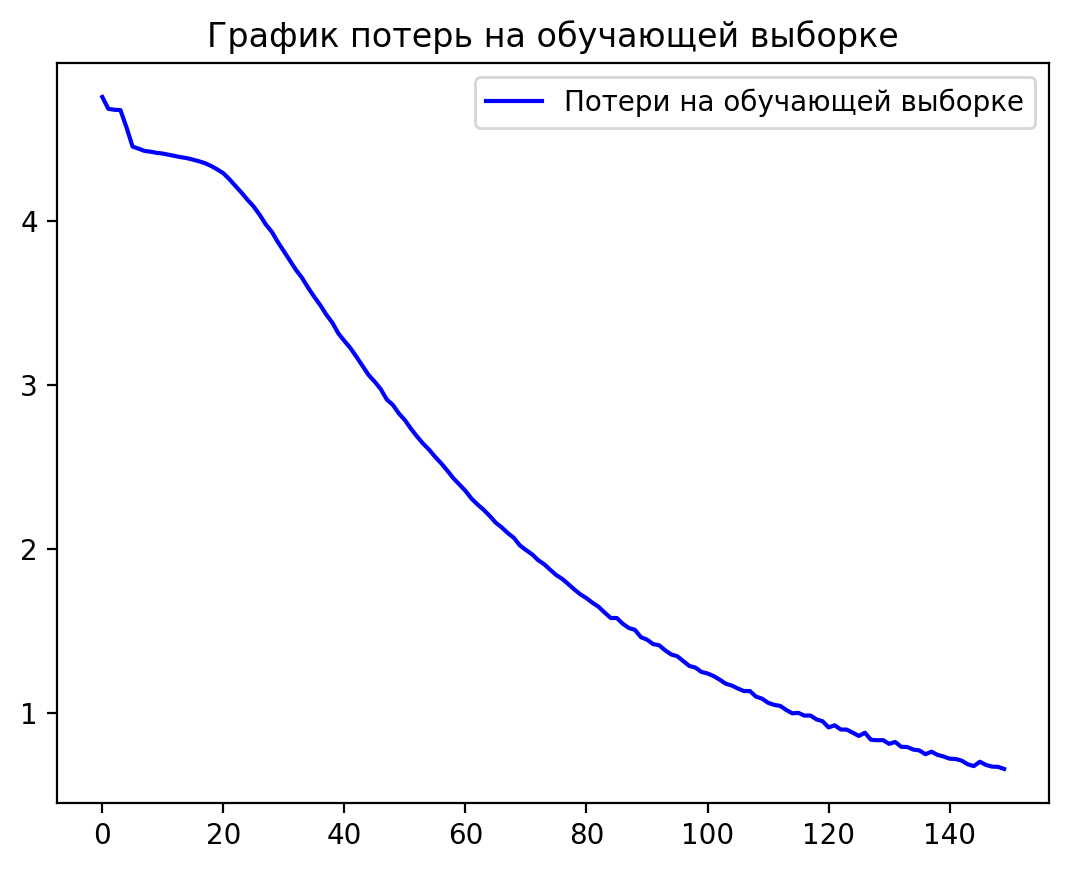

In [ ]:
plt.plot(history.epoch, history.history['acc'], 'r', label='Точность на обучающей выборке')
plt.title('График точности на обучающей выборке')
plt.legend()
plt.figure()
plt.plot(history.epoch, history.history['loss'], 'b', label='Потери на обучающей выборке')
plt.title('График потерь на обучающей выборке')
plt.legend()
plt.show()

В качестве начальной последовательности для генерации используйте произведения Моцарта.
Для получения трех баллов достаточно получить ноты и аудиофайл с вашим сгенерированным произведением.

In [ ]:
from music21 import *
import os
import numpy as np
import pandas as pd
from collections import Counter
import random
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings


In [ ]:
# Настройки окружения
us = environment.UserSettings()
us['musescoreDirectPNGPath'] = '/usr/bin/mscore'
us['directoryScratch'] = '/tmp'

# Игнорирование предупреждений
warnings.filterwarnings("ignore")
np.random.seed(42)

In [ ]:
# Разархивируем датасет во временную папку 'dataset'
!unzip -qo "classical-music-midi" -d ./dataset

In [ ]:
# Задаем список композиторов
CLASS_LIST = ["Mozart"]
all_midis = []

# Загружаем MIDI-файлы
for compositor in CLASS_LIST:
    filepath = f"./dataset/{compositor}/"
    for i in os.listdir(filepath):
        if i.endswith(".mid"):
            tr = filepath + i
            midi = converter.parse(tr)
            all_midis.append(midi)

In [ ]:
# Функция для извлечения нот
def getNotes(file):
    notes = []
    for j in file:
        songs = instrument.partitionByInstrument(j)
        for part in songs.parts:
            notes_to_parse = part.recurse()
            for element in notes_to_parse:
                if isinstance(element, note.Note):
                    notes.append(str(element.pitch))
                elif isinstance(element, chord.Chord):
                    notes.append(".".join(str(n) for n in element.normalOrder))
    return notes

# Получаем ноты из произведений Моцарта
Corpus = getNotes(all_midis)
print("Всего нот во всех midi-файлах всего датасета:", len(Corpus))

In [ ]:
# Функция преобразования отрывка из корпуса обратно в поток
def chords_n_notes(chunk):
    Melody = []
    offset = 0
    for i in chunk:
        if ("." in i or i.isdigit()):
            chord_notes = i.split(".")
            notes = []
            for j in chord_notes:
                inst_note = int(j)
                note_chunk = note.Note(inst_note)
                notes.append(note_chunk)
                chord_chunk = chord.Chord(notes)
                chord_chunk.offset = offset
                Melody.append(chord_chunk)
        else:
            note_chunk = note.Note(i)
            note_chunk.offset = offset
            Melody.append(note_chunk)
        offset += 1
    return Melody

# Сохраняем все уникальные значения корпуса
symb = sorted(list(set(Corpus)))
mapping = dict((c, i) for i, c in enumerate(symb))
reverse_mapping = dict((i, c) for i, c in enumerate(symb))

In [ ]:
# Разбиение корпуса на входные и целевые последовательности
length = 40
features = []
targets = []

for i in range(0, len(Corpus) - length, 1):
    feature = Corpus[i:i + length]
    target = Corpus[i + length]
    features.append([mapping[j] for j in feature])
    targets.append(mapping[target])

L_datapoints = len(targets)
X = (np.reshape(features, (L_datapoints, length, 1))) / float(len(symb))
y = tensorflow.keras.utils.to_categorical(targets)

In [ ]:
X_train, X_seed, y_train, y_seed = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание модели
model = Sequential()
model.add(LSTM(256, input_shape=X.shape[1:], return_sequences=True))
model.add(Dropout(0.1))
model.add(LSTM(128))
model.add(Dense(128))
model.add(Dropout(0.1))
model.add(Dense(y.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['acc'])
history = model.fit(X_train, y_train, batch_size=256, epochs=150)

In [ ]:
# Генерация последовательности
def generate_notes(model, start, n_notes):
    pattern = [mapping[note] for note in start]
    prediction_output = []

    for note_index in range(n_notes):
        input_pattern = np.reshape(pattern, (1, len(pattern), 1))
        input_pattern = input_pattern / float(len(symb))

        prediction = model.predict(input_pattern, verbose=0)
        index = np.argmax(prediction)
        result = reverse_mapping[index]
        prediction_output.append(result)

        pattern.append(index)
        pattern = pattern[1:]

    return prediction_output

# Задаем начальную последовательность
start_sequence = Corpus[:40]
generated_notes = generate_notes(model, start_sequence, 100)  # генерируем 100 нот

# Преобразуем сгенерированные ноты в MIDI
Melody = chords_n_notes(generated_notes)
Melody_midi = stream.Stream(Melody)

Всего нот во всех midi-файлах всего датасета: 55802
Epoch 1/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0364 - loss: 4.4807
Epoch 2/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0339 - loss: 4.2735
Epoch 3/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.0388 - loss: 4.2596
Epoch 4/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0384 - loss: 4.2424
Epoch 5/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.0373 - loss: 4.1927
Epoch 6/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0390 - loss: 4.1681
Epoch 7/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0405 - loss: 4.1557
Epoch 8/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0411 - loss: 4.1425
Epoch 9/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0422 - loss: 4.1399
Epoch 10/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.0438 - loss: 4.1316
Epoch 11/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0437 - loss: 4.1305
Epoch 12/150
175/175 ━━━━━━━━━━━━

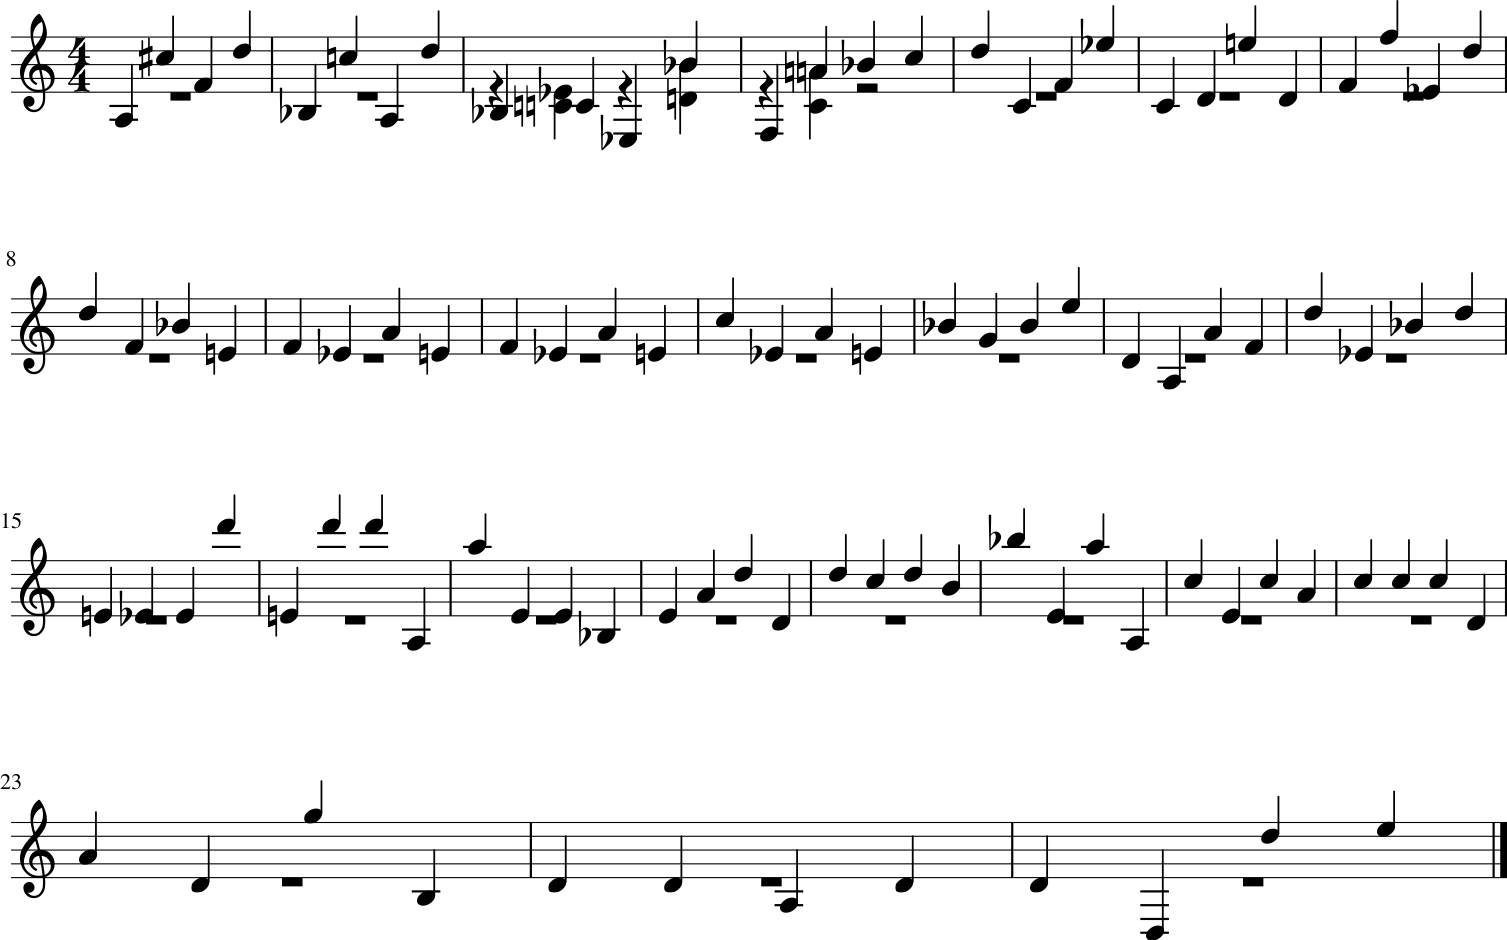

Сгенерированная музыка сохранена в файл 'generated_mozart.mid'.


In [ ]:
# Сохраняем в MIDI файл
Melody_midi.write('midi', fp='generated_mozart.mid')

# Отобразим нотный стан
Melody_midi.show()

# Выводим в виде звуковой дорожки
Melody_midi.show('midi')

print("Сгенерированная музыка будет  сохранена в файл 'generated_mozart.mid'.")

Хотите 4 балла? Добавьте в функцию генерации параметр temperature - температура модели. Температура модели влияет на генерацию. Более низкие температуры соответствуют более точному предсказанию, а более высокие температуры приводят к более случайной генерации.

In [ ]:
from music21 import *
import os
import numpy as np
import random
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
import warnings

# Игнорирование предупреждений
warnings.filterwarnings("ignore")
np.random.seed(42)

In [ ]:
# Задаем список композиторов
CLASS_LIST = ["Mozart"]
all_midis = []

# Загружаем MIDI-файлы
for compositor in CLASS_LIST:
    filepath = f"./dataset/{compositor}/"
    for i in os.listdir(filepath):
        if i.endswith(".mid"):
            tr = filepath + i
            midi = converter.parse(tr)
            all_midis.append(midi)


In [ ]:
# Функция для извлечения нот
def getNotes(file):
    notes = []
    for j in file:
        songs = instrument.partitionByInstrument(j)
        for part in songs.parts:
            notes_to_parse = part.recurse()
            for element in notes_to_parse:
                if isinstance(element, note.Note):
                    notes.append(str(element.pitch))
                elif isinstance(element, chord.Chord):
                    notes.append(".".join(str(n) for n in element.normalOrder))
    return notes

# Получаем ноты из произведений Моцарта
Corpus = getNotes(all_midis)
print("Всего нот во всех midi-файлах всего датасета:", len(Corpus))

In [ ]:
# Функция преобразования отрывка из корпуса обратно в поток
def chords_n_notes(chunk):
    Melody = []
    offset = 0
    for i in chunk:
        if ("." in i or i.isdigit()):
            chord_notes = i.split(".")
            notes = []
            for j in chord_notes:
                inst_note = int(j)
                note_chunk = note.Note(inst_note)
                notes.append(note_chunk)
                chord_chunk = chord.Chord(notes)
                chord_chunk.offset = offset
                Melody.append(chord_chunk)
        else:
            note_chunk = note.Note(i)
            note_chunk.offset = offset
            Melody.append(note_chunk)
        offset += 1
    return Melody

In [ ]:
# Сохраняем все уникальные значения корпуса
symb = sorted(list(set(Corpus)))
mapping = dict((c, i) for i, c in enumerate(symb))
reverse_mapping = dict((i, c) for i, c in enumerate(symb))

# Разбиение корпуса на входные и целевые последовательности
length = 40
features = []
targets = []

for i in range(0, len(Corpus) - length, 1):
    feature = Corpus[i:i + length]
    target = Corpus[i + length]
    features.append([mapping[j] for j in feature])
    targets.append(mapping[target])

L_datapoints = len(targets)
X = (np.reshape(features, (L_datapoints, length, 1))) / float(len(symb))
y = tensorflow.keras.utils.to_categorical(targets)

X_train, X_seed, y_train, y_seed = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = Sequential()
model.add(LSTM(256, input_shape=(X_train.shape[1], 1), return_sequences=True))
model.add(Dropout(0.1))
model.add(LSTM(128))
model.add(Dense(128))
model.add(Dropout(0.1))
model.add(Dense(len(symb), activation='softmax'))

#
model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['acc'])
model.fit(X_train, y_train, batch_size=256, epochs=150)

In [ ]:
def generate_notes(model, start, n_notes, temperature=1.0):
    pattern = [mapping[note] for note in start]
    prediction_output = []

    for note_index in range(n_notes):
        input_pattern = np.reshape(pattern, (1, len(pattern), 1))
        input_pattern = input_pattern / float(len(symb))

        prediction = model.predict(input_pattern, verbose=0)[0]


        prediction = np.log(prediction + 1e-10) / temperature
        exp_preds = np.exp(prediction)
        prediction = exp_preds / np.sum(exp_preds)

        index = np.random.choice(range(len(prediction)), p=prediction)
        result = reverse_mapping[index]
        prediction_output.append(result)

        pattern.append(index)
        pattern = pattern[1:]

    return prediction_output


In [ ]:
# Преобразуем ноты в поток и сохраняем в MIDI файл
def create_midi(prediction_output):
    offset = 0
    output_notes = []

    for pattern in prediction_output:
        if ('.' in pattern) or pattern.isdigit():
            chord_notes = pattern.split('.')
            notes = []
            for n in chord_notes:
                notes.append(note.Note(int(n)))
            new_chord = chord.Chord(notes)
            new_chord.offset = offset
            output_notes.append(new_chord)
        else:
            new_note = note.Note(pattern)
            new_note.offset = offset
            output_notes.append(new_note)
        offset += 0.5

    midi_stream = stream.Stream(output_notes)
    midi_stream.write('midi', fp='generated_mozart.mid')

# Задаем начальную последовательность и генерируем ноты
start_sequence = Corpus[:40]
generated_notes = generate_notes(model, start_sequence, 100, temperature=0.5)  # Генерация с температурой 0.5


In [ ]:
# Создаем MIDI файл из сгенерированных нот
create_midi(generated_notes)
print("Сгенерированная музыка сохранена в файл 'generated_mozart.mid'.")


Всего нот во всех midi-файлах всего датасета: 55802
Epoch 1/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - acc: 0.0326 - loss: 4.5056
Epoch 2/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0362 - loss: 4.2753
Epoch 3/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.0369 - loss: 4.2626
Epoch 4/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0387 - loss: 4.1926
Epoch 5/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0395 - loss: 4.1497
Epoch 6/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.0416 - loss: 4.1688
Epoch 7/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0419 - loss: 4.1456
Epoch 8/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0461 - loss: 4.1354
Epoch 9/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0466 - loss: 4.1243
Epoch 10/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.0506 - loss: 4.0923
Epoch 11/150
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.0553 - loss: 4.0705
Epoch 12/150
175/175 ━━━━━━━━━━━━

Используйте для обучения модели три переменные для представления ноты: pitch, step и duration. Высота звука (pitch) - это качество восприятия звука в виде номера ноты в формате MIDI. Шаг (step) - это время, прошедшее с предыдущей ноты или начала трека. Длительность (duration) - это продолжительность воспроизведения ноты в секундах и разница между временем окончания и началом ноты.

In [ ]:
from music21 import *
import os
import numpy as np
import random
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
import warnings

# Игнорирование предупреждений
warnings.filterwarnings("ignore")
np.random.seed(42)

In [ ]:
# Задаем список композиторов
CLASS_LIST = ["Mozart"]
all_midis = []

# Загружаем MIDI-файлы
for compositor in CLASS_LIST:
    filepath = f"./dataset/{compositor}/"
    for i in os.listdir(filepath):
        if i.endswith(".mid"):
            tr = filepath + i
            midi = converter.parse(tr)
            all_midis.append(midi)

FileNotFoundError: [Errno 2] No such file or directory: './dataset/Mozart/'

In [ ]:
# Функция для извлечения нот, шага и длительности
def getNotes(file):
    notes = []
    for j in file:
        songs = instrument.partitionByInstrument(j)
        for part in songs.parts:
            notes_to_parse = part.recurse()
            previous_note_end_time = 0  # Для расчета шага
            for element in notes_to_parse:
                if isinstance(element, note.Note):
                    pitch = str(element.pitch)
                    duration = element.quarterLength
                    step = element.offset - previous_note_end_time
                    notes.append((pitch, step, duration))
                    previous_note_end_time = element.offset + duration
                elif isinstance(element, chord.Chord):
                    pitch = ".".join(str(n) for n in element.normalOrder)
                    duration = element.quarterLength
                    step = element.offset - previous_note_end_time
                    notes.append((pitch, step, duration))
                    previous_note_end_time = element.offset + duration
    return notes

# Получаем ноты из произведений Моцарта
Corpus = getNotes(all_midis)
print("Всего нот во всех midi-файлах всего датасета:", len(Corpus))

In [ ]:


# Сохраняем все уникальные значения корпуса
pitches = sorted(list(set(note[0] for note in Corpus)))
steps = sorted(list(set(note[1] for note in Corpus)))
durations = sorted(list(set(note[2] for note in Corpus)))

pitch_mapping = {pitch: i for i, pitch in enumerate(pitches)}
step_mapping = {step: i for i, step in enumerate(steps)}
duration_mapping = {duration: i for i, duration in enumerate(durations)}

# Разбиение корпуса на входные и целевые последовательности
length = 40
features = []
targets = []

for i in range(0, len(Corpus) - length):
    feature = Corpus[i:i + length]
    target = Corpus[i + length]
    features.append(feature)
    targets.append(target)

In [ ]:
L_datapoints = len(targets)
X_encoded = []

for feature in features:
    encoded_feature = [
        [pitch_mapping[note[0]], step_mapping[note[1]], duration_mapping[note[2]]]
        for note in feature
    ]
    X_encoded.append(encoded_feature)

X = np.array(X_encoded).reshape(L_datapoints, length, 3)
y = tensorflow.keras.utils.to_categorical([pitch_mapping[note[0]] for note in targets], num_classes=len(pitch_mapping))

X_train, X_seed, y_train, y_seed = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = Sequential()
model.add(LSTM(256, input_shape=(X_train.shape[1], 3), return_sequences=True))  # Изменяем input_shape на 3
model.add(Dropout(0.1))
model.add(LSTM(128))
model.add(Dense(128))
model.add(Dropout(0.1))
model.add(Dense(len(pitch_mapping), activation='softmax'))  # Изменяем выходной слой для высоты звука

# Компиляция и обучение модели
model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['acc'])
model.fit(X_train, y_train, batch_size=256, epochs=150)

In [ ]:
# Генерация музыкальной последовательности с учетом температуры
def generate_notes(model, start, n_notes, temperature=1.0):
    pattern = [pitch_mapping[note[0]] for note in start]
    prediction_output = []

    for note_index in range(n_notes):
        input_pattern = np.reshape(pattern, (1, len(pattern), 1))
        input_pattern = input_pattern / float(len(pitches))

        prediction = model.predict(input_pattern, verbose=0)[0]

        # Применяем температуру
        prediction = np.log(prediction + 1e-10) / temperature
        exp_preds = np.exp(prediction)  # Обратное преобразование
        prediction = exp_preds / np.sum(exp_preds)

        index = np.random.choice(range(len(prediction)), p=prediction)
        result_pitch = reverse_mapping[index]

        # Получаем step и duration из предыдущей ноты
        if prediction_output:
            last_note = prediction_output[-1]
            last_step = last_note[1]
            last_duration = last_note[2]
        else:
            last_step = 0
            last_duration = 1  # Начальная длительность

        # Добавляем новую ноту в выходной список
        prediction_output.append((result_pitch, last_step, last_duration))

        # Обновляем паттерн
        pattern.append(index)
        pattern = pattern[1:]

    return prediction_output


In [ ]:
# Преобразуем ноты в поток и сохраняем в MIDI файл
def create_midi(prediction_output):
    offset = 0
    output_notes = []

    for pattern in prediction_output:
        pitch, step, duration = pattern  # Распаковка кортежа
        if ('.' in pitch) or pitch.isdigit():
            chord_notes = pitch.split('.')
            notes = []
            for n in chord_notes:
                notes.append(note.Note(int(n)))
            new_chord = chord.Chord(notes)
            new_chord.offset = offset
            output_notes.append(new_chord)
        else:
            new_note = note.Note(pitch)
            new_note.offset = offset
            output_notes.append(new_note)

        offset += step + duration

    midi_stream = stream.Stream(output_notes)
    midi_stream.write('midi', fp='generated_mozart.mid')

start_sequence = Corpus[:40]
generated_notes = generate_notes(model, start_sequence, 100, temperature=0.5)


In [ ]:
create_midi(generated_notes)
print("Сгенерированная музыка сохранена в  файл 'generated_mozart.mid'.")
